# Identifying Treated Wastewater Discharges to Lough Neagh

- This notebook documents the workflow used to identify treated wastewater discharges that ultimately flow into Lough Neagh.
- It includes data preparation, spatial filtering of discharges within relevant Local Management Areas, and the creation of a geospatial map showing the locations of these discharges.
- The mapping workflow uses UTM projection for analysis and converts polygon layers to geographic coordinates (EPSG:4326) for stable rendering in Cartopy.

## Introduction

Explain:

what the notebook does
why Lough Neagh is being studied
datasets used


## Load Geospatial and Plotting Libraries

In [1]:
# IMPORTS FOR GEOSPATIAL DATA, MAPPING, AND PLOTTING

import os
import geopandas as gpd
import matplotlib.pyplot as plt
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

## Helper Functions for Map Visualisation

In [2]:
# HELPER FUNCTIONS FOR LEGEND HANDLES AND SCALE BAR

def generate_handles(labels, colors, edge='k', alpha=1):
    """
    Generate matplotlib patch handles to create a legend of each of the features in the map.

    Parameters
    ----------

    labels : list(str)
        the text labels of the features to add to the legend

    colors : list(matplotlib color)
        the colors used for each of the features included in the map.

    edge : matplotlib color (default: 'k')
        the color to use for the edge of the legend patches.

    alpha : float (default: 1.0)
        the alpha value to use for the legend patches.

    Returns
    -------

    handles : list(matplotlib.patches.Rectangle)
        the list of legend patches to pass to ax.legend()
    """
    lc = len(colors)  # get the length of the color list
    handles = [] # create an empty list
    for ii in range(len(labels)): # for each label and color pair that we're given, make an empty box to pass to our legend
        handles.append(mpatches.Rectangle((0, 0), 1, 1, facecolor=colors[ii % lc], edgecolor=edge, alpha=alpha))
    return handles

def scale_bar(ax, length=20, location=(0.92, 0.95)):
    """
    Create a scale bar in a cartopy GeoAxes.

    Parameters
    ----------

    ax : cartopy.mpl.geoaxes.GeoAxes
        the cartopy GeoAxes to add the scalebar to.

    length : int, float (default 20)
        the length of the scalebar, in km

    location : tuple(float, float) (default (0.92, 0.95))
        the location of the center right corner of the scalebar, in fractions of the axis.

    Returns
    -------
    ax : cartopy.mpl.geoaxes.GeoAxes
        the cartopy GeoAxes object

    """
    x0, x1, y0, y1 = ax.get_extent() # get the current extent of the axis
    sbx = x0 + (x1 - x0) * location[0] # get the right x coordinate of the scale bar
    sby = y0 + (y1 - y0) * location[1] # get the right y coordinate of the scale bar

    ax.plot([sbx, sbx-length*1000], [sby, sby], color='k', linewidth=4, transform=ax.projection) # plot a thick black line
    ax.plot([sbx-(length/2)*1000, sbx-length*1000], [sby, sby], color='w', linewidth=2, transform=ax.projection) # plot a white line from 0 to halfway

    ax.text(sbx, sby-(length/4)*1000, f"{length} km", ha='center', transform=ax.projection, fontsize=6) # add a label at the right side
    ax.text(sbx-(length/2)*1000, sby-(length/4)*1000, f"{int(length/2)} km", ha='center', transform=ax.projection, fontsize=6) # add a label in the center
    ax.text(sbx-length*1000, sby-(length/4)*1000, '0 km', ha='center', transform=ax.projection, fontsize=6) # add a label at the left side

    return ax


In [3]:
# LOAD OUTLINE AND WATER SHAPEFILES

outline = gpd.read_file('../Data/NI_outline.shp')
water = gpd.read_file('../Data/Water.shp')
lmas = gpd.read_file('../Data/LMAs.shp')
discharges = gpd.read_file('../Data/treated_discharges.shp')
waterbodies = gpd.read_file('../Data/WFD_River_Water_Bodies_2016.shp')


# FILTER LMAs CONNECTED TO LOUGH NEAGH 

target_lmas = [
    "Lough Neagh",
    "River Blackwater",
    "Upper Bann",
    "Moyola",
    "Ballinderry",
    "Six Mile Water"
]

# Select only these LMAs
selected_lmas = lmas[lmas["NAME"].isin(target_lmas)]

# Select only discharges inside these LMAs
discharges_in_lmas = gpd.sjoin(
    discharges,
    selected_lmas,
    how="inner",
    predicate="intersects"
)

C:\Users\Macki\anaconda3\envs\lough-neagh-discharges\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: ../Data/WFD_River_Water_Bodies_2016.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


<GeoAxes: >

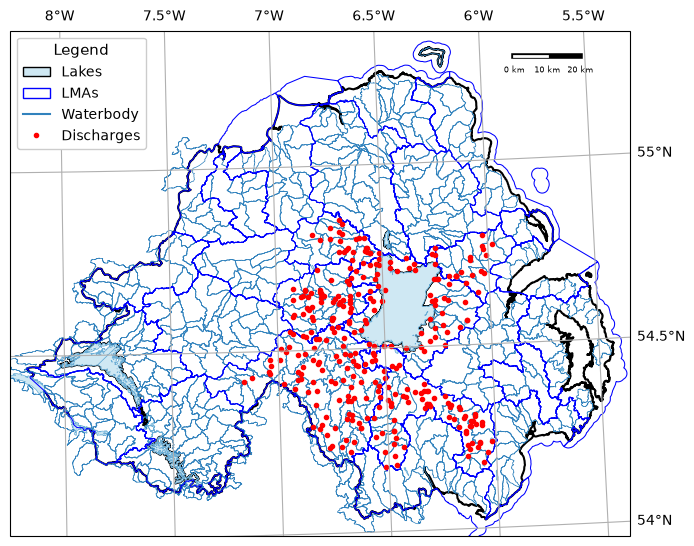

In [4]:
# SET UP MAP PROJECTION AND FIGURE


# UTM Zone 29 (NI)
ni_utm = ccrs.UTM(29)  

# Reproject project layers to match outline CRS
lmas = lmas.to_crs(outline.crs)
discharges = discharges.to_crs(outline.crs)
waterbodies = waterbodies.to_crs(outline.crs)

# Create a figure size 8x8
fig = plt.figure(figsize=(8, 8))

# Creates axes with UTM projection
ax = plt.axes(projection=ni_utm)  

# Add NI outline

outline_ll = outline.to_crs(epsg=4326)

outline_feature = ShapelyFeature(
    outline_ll['geometry'],
    ccrs.PlateCarree(),
    edgecolor='k',   # black boundary
    facecolor='none',# transparent fill (recommended)
    linewidth=1.5      # thicker outline
)

# Add all features to the map
ax.add_feature(outline_feature) # add the features to the map.

# Map extent using outline bounds
xmin, ymin, xmax, ymax = outline.total_bounds
ax.set_extent([xmin-5000, xmax+5000, ymin-5000, ymax+5000], crs=ni_utm)  

# Convert water to lon/lat (EPSG:4326). Cartopy expects ShapelyFeature geometry in PlateCarree,
# even when the map projection is UTM. This prevents extent warnings and ensures correct rendering.
water_ll = water.to_crs(epsg=4326)

# Add water features using lon/lat geometry and PlateCarree CRS, set colours and outline width
water_feat = ShapelyFeature(
    water_ll['geometry'], 
    ccrs.PlateCarree(),
    edgecolor='#6baed6',   # lighter outline
    facecolor='#cfe8f3',   # Very light fill
    linewidth=0.5
)
ax.add_feature(water_feat)


lake_handle = generate_handles(['Lakes'], ['#cfe8f3'])

# ADD ALL PROJECT ANALYSIS LAYERS

# Add Local Management Areas, Treated Effluent Discharges and Waterbodies features

# Plot discharges in selected LMAs only
discharge_handle = ax.plot(
    discharges_in_lmas.geometry.x,
    discharges_in_lmas.geometry.y,
    'o',
    color='red',
    markersize=3,
    transform=ccrs.CRS(discharges_in_lmas.crs)
)

# Convert waterbodies to EPSG:4326 (lon/lat). Cartopy requires ShapelyFeature geometry in PlateCarree,
# even when the map projection is UTM. This avoids Cartopy extent warnings and ensures correct rendering.

waterbodies_ll = waterbodies.to_crs(epsg=4326)

# Add waterbody features using geographic CRS (PlateCarree), set colours and outline width
waterbody_feat = ShapelyFeature(
    waterbodies_ll['geometry'],
    ccrs.PlateCarree(),
    edgecolor='#3182bd',   # medium blue
    facecolor='none',
    linewidth=0.5
)
ax.add_feature(waterbody_feat)

waterbody_handle = [mlines.Line2D([], [], color='#3182bd')]


# Convert LMAs to EPSG:4326 (lon/lat). Cartopy requires ShapelyFeature geometry in PlateCarree,
# even when the map projection is UTM. This avoids Cartopy extent warnings and ensures correct rendering.

lmas_ll = lmas.to_crs(epsg=4326)

# Add LMA features using geographic CRS (PlateCarree), set colours and outline width
lma_feat = ShapelyFeature(
    lmas_ll['geometry'],
    ccrs.PlateCarree(),
    edgecolor='blue',   # standard blue
    facecolor='none',
    linewidth=0.75
)
ax.add_feature(lma_feat)

# CREATE LEGEND

water_handle = generate_handles(['Lakes'], ['mediumblue'])

lma_handle = [mpatches.Patch(
    facecolor='none',
    edgecolor='blue',       # matches LMAs on map
    label='LMAs'
)]

waterbody_handle = [mlines.Line2D(
    [], [], 
    color='#3182bd',        # matches waterbody lines
    label='Waterbody'
)]

discharge_handle = [mlines.Line2D(
    [], [], 
    color='red', 
    marker='o', 
    linestyle='None', 
    markersize=3,
    label='Discharges'
)]

handles = lake_handle + lma_handle + waterbody_handle + discharge_handle
labels = ['Lakes', 'LMAs', 'Waterbody', 'Discharges']

ax.legend(
    handles, labels,
    title='Legend',
    title_fontsize=11,
    fontsize=10,
    loc='upper left',
    frameon=True,
    framealpha=1
)


# ADD GRIDLINES AND SCALE BAR

gridlines = ax.gridlines(draw_labels=True, # Draw  labels for the grid lines
xlocs=[-8, -7.5, -7, -6.5, -6, -5.5], # add longitude lines at 0.5 deg intervals
ylocs=[54, 54.5, 55, 55.5]) # add latitude lines at 0.5 deg intervals
gridlines.left_labels = False # turn off the left-side labels
gridlines.bottom_labels = False # turn off the bottom labels

# Add a scale bar to the axis
scale_bar(ax)



## Methodology

The analysis identifies treated wastewater discharge points that
drain to Lough Neagh. Spatial selection and catchment analysis are
used to determine which discharges contribute to the Lough Neagh
system.

## Select Relevant Discharges

In [ ]:
## Create Map

In [5]:
# SAVE LOUGH NEAGH ANALYSIS FIGURE

# Save figure as lough_neagh_map.png, crop to the axis ('tight') with dpi of 300
fig.savefig("../Outputs/Map of Lough Neagh Treated Discharges.png", bbox_inches='tight', dpi=300)

## Create Table Output

In [6]:
# IMPORTS FOR GEOSPATIAL DATA ANALYSIS

import geopandas as gpd
import pandas as pd

# LOAD ANALYSIS LAYERS
lmas = gpd.read_file('../Data/LMAs.shp')
discharges = gpd.read_file('../Data/treated_discharges.shp')
waterbodies = gpd.read_file('../Data/WFD_River_Water_Bodies_2016.shp')

# REPROJECT LAYERS TO COMMON CRS
discharges = discharges.to_crs(lmas.crs)
waterbodies = waterbodies.to_crs(lmas.crs)

# DEFINE LMAs IN THE LOUGH NEAGH CATCHMENT

target_lmas = [
    "Lough Neagh",
    "River Blackwater",
    "Upper Bann",
    "Moyola",
    "Ballinderry",
    "Six Mile Water"
]

# LOOP THROUGH LMAs / PREPARE GEOMETRY FOR SPATIAL FILTERING

results = []

for name in target_lmas:
    lma_poly = lmas[lmas["NAME"] == name]

    if lma_poly.empty:
        print(f"WARNING: LMA '{name}' not found.")
        continue
    
    geom = lma_poly.geometry.union_all()

    
# SELECT DISCHARGES INCLUDE THE LMAs
    subset = discharges[discharges.within(geom)].copy()
    subset["LMA"] = name

    results.append(subset)
    

# COMBINE RESULTS INTO A TABLE
if results:
    combined = pd.concat(results, ignore_index=True)

# SPATIAL JOIN TO ADD NAMESPACE AND BUILD OUTPUT TABLE

    combined = gpd.sjoin(
        combined,
        waterbodies[["namespace", "geometry"]],
        how="left",
        predicate="within"
    )

output = pd.DataFrame({
        "Name": combined["Name"],
        "LMA": combined["LMA"],
        "Namespace": combined["namespace"]
})


print("\nSummary of discharges inside selected LMAs:")
print(output)

# EXPORT TO EXCEL

output.to_excel("../Outputs/Lough_Neagh_Treated_Discharges.xlsx", index=False)


C:\Users\Macki\anaconda3\envs\lough-neagh-discharges\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: ../Data/WFD_River_Water_Bodies_2016.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(



Summary of discharges inside selected LMAs:
                             Name             LMA                Namespace
0                 Aghagallon WwTW     Lough Neagh  Lough Neagh Peripherals
1                    Aghalee WwTW     Lough Neagh  Lough Neagh Peripherals
2       Annaghmore Portadown WwTW     Lough Neagh          Derrycaw Stream
3      Annaghmore Road Ballina ST     Lough Neagh  Lough Neagh Peripherals
4            Antrim Milltown WwTW     Lough Neagh  Lough Neagh Peripherals
..                            ...             ...                      ...
314                Roughfort WwTW  Six Mile Water        Ballymartin Water
315  Seven Mile Straight 78-80 ST  Six Mile Water  Six mile Water (Antrim)
316  Seven Mile Straight 82-84 ST  Six Mile Water  Six mile Water (Antrim)
317  Seven Mile Straight 86-88 ST  Six Mile Water  Six mile Water (Antrim)
318  Shaneoguestown Road 38-40 ST  Six Mile Water  Six mile Water (Antrim)

[319 rows x 3 columns]


## Results

## Conclusions


- Treated wastewater discharges contributing to Lough Neagh were identified.
- An output map was successfully generated.
- The workflow can be repeated with updated datasets.
